# 📋 Data Quality Report

Visual summary of completeness, distributions, and validation results for all three raw datasets:
- **AIS** — vessel position pings (sampled: 1 file)
- **Cetacean** — whale/dolphin sightings from OBIS
- **MPA** — Marine Protected Areas from NOAA

This notebook re-uses the helper functions from `pipeline.validation.quality_report` and adds matplotlib charts.

In [14]:
import sys
from pathlib import Path

# Add project root to path so 'pipeline' package is importable
PROJECT_ROOT = Path.cwd().parents[1]  # notebooks/data_quality → project root
sys.path.insert(0, str(PROJECT_ROOT))

In [15]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

from pipeline.validation.quality_report import (
    completeness_report,
)
from pipeline.validation.schemas import (
    ais_schema,
    cetacean_schema,
    mpa_schema,
    validate_dataframe,
)

# Data paths (relative to project root)
AIS_DIR = PROJECT_ROOT / "data/raw/ais"
CETACEAN_FILE = PROJECT_ROOT / "data/raw/cetacean/us_cetacean_sightings.parquet"
MPA_FILE = PROJECT_ROOT / "data/raw/mpa/mpa_inventory.parquet"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## 1. Load all datasets

In [6]:
# Cetacean sightings
cet_df = pd.read_parquet(CETACEAN_FILE)
print(f"Cetacean: {len(cet_df):,} rows, {cet_df.shape[1]} columns")

# MPA
mpa_gdf = gpd.read_parquet(MPA_FILE)
print(f"MPA: {len(mpa_gdf):,} rows, {mpa_gdf.shape[1]} columns")

# AIS (sample first file)
ais_files = sorted(AIS_DIR.glob("*.parquet"))
ais_df = pd.read_parquet(ais_files[0])
print(
    f"AIS sample ({ais_files[0].name}): {len(ais_df):,} rows, {ais_df.shape[1]} columns"
)
print(f"AIS total files: {len(ais_files)}")

Cetacean: 460,212 rows, 10 columns
MPA: 843 rows, 36 columns
AIS sample (ais-2024-01-01.parquet): 7,293,408 rows, 16 columns
AIS total files: 366


## 2. Schema validation

In [7]:
# Run Pandera validation on all three datasets
validations = {
    "Cetacean": validate_dataframe(cet_df, cetacean_schema),
    "MPA": validate_dataframe(mpa_gdf, mpa_schema),
    "AIS (sample)": validate_dataframe(ais_df, ais_schema),
}

summary = pd.DataFrame(
    [
        {
            "Dataset": name,
            "Rows": f"{v['n_rows']:,}",
            "Status": "✅ PASS" if v["valid"] else "❌ FAIL",
            "Failures": v["n_failures"],
        }
        for name, v in validations.items()
    ]
)
summary.style.hide(axis="index")

Dataset,Rows,Status,Failures
Cetacean,"460,212",✅ PASS,0
MPA,843,✅ PASS,0
AIS (sample),"7,293,408",✅ PASS,0


## 3. Column completeness

Percentage of non-null values per column. Columns below 80% may need special handling downstream.

In [8]:
def plot_completeness(df, title):
    """Horizontal bar chart of column completeness."""
    comp = completeness_report(df, title)
    comp = comp.sort_values("completeness_pct")

    colours = [
        "#e74c3c" if v < 80 else "#f39c12" if v < 95 else "#2ecc71"
        for v in comp["completeness_pct"]
    ]

    fig, ax = plt.subplots(figsize=(10, max(4, len(comp) * 0.35)))
    ax.barh(comp["column"], comp["completeness_pct"], color=colours)
    ax.set_xlim(0, 105)
    ax.axvline(x=80, color="#e74c3c", linestyle="--", alpha=0.5, label="80%")
    ax.axvline(x=95, color="#f39c12", linestyle="--", alpha=0.5, label="95%")
    ax.set_xlabel("Completeness (%)")
    ax.set_title(f"Column Completeness — {title}")
    ax.legend()
    plt.tight_layout()
    plt.show()

2026-02-23 17:03:49,973 - INFO - 
📊 Completeness — AIS (sample) (7293408 rows)
        column  non_null_count  total_rows  completeness_pct
          mmsi         7293408     7293408            100.00
base_date_time         7293408     7293408            100.00
           sog         7276775     7293408             99.77
           cog         6083090     7293408             83.41
       heading         3467633     7293408             47.54
   vessel_name         7293408     7293408            100.00
           imo         7293408     7293408            100.00
     call_sign         7293408     7293408            100.00
   vessel_type         7255303     7293408             99.48
        status         4849705     7293408             66.49
        length         7152775     7293408             98.07
         width         7077032     7293408             97.03
         draft         4234610     7293408             58.06
         cargo         5067320     7293408             69.48
   tra

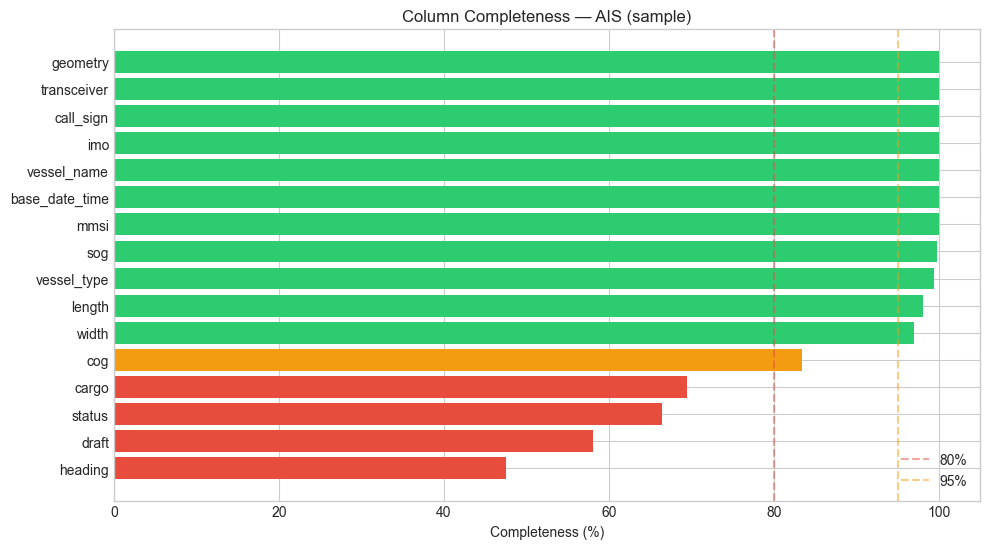

In [9]:
plot_completeness(ais_df, "AIS (sample)")

2026-02-23 17:03:50,041 - INFO - 
📊 Completeness — Cetacean Sightings (460212 rows)
          column  non_null_count  total_rows  completeness_pct
  scientificName          460212      460212            100.00
 decimalLatitude          460212      460212            100.00
decimalLongitude          460212      460212            100.00
       eventDate          459608      460212             99.87
       date_year          417301      460212             90.68
           order          460212      460212            100.00
          family          437144      460212             94.99
         species          409523      460212             88.99
         dropped          460212      460212            100.00
         absence          460212      460212            100.00


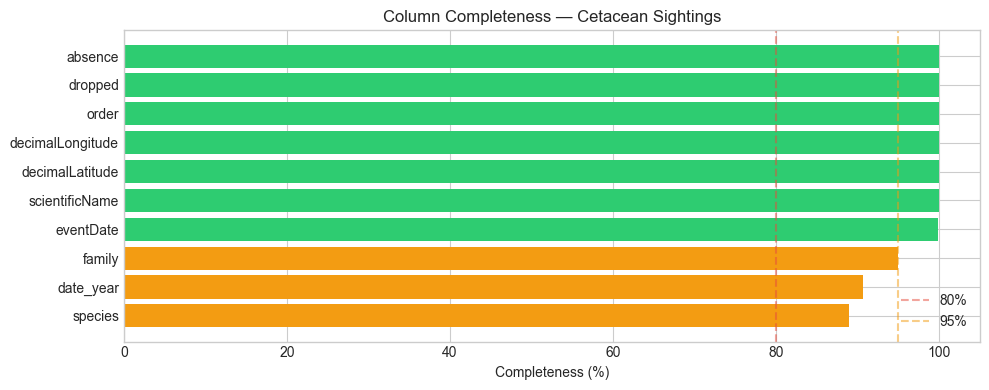

In [10]:
plot_completeness(cet_df, "Cetacean Sightings")

## 4. AIS key distributions

Speed over ground and vessel type are the two most important AIS columns for risk modelling.

2026-02-23 17:03:50,414 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-23 17:03:50,415 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


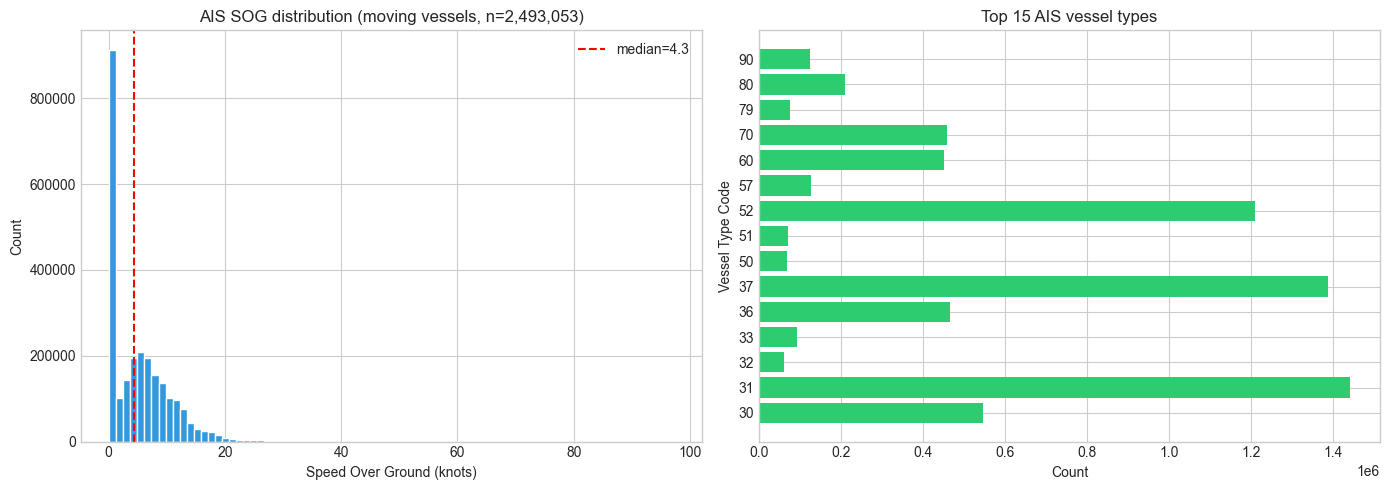

Stationary (SOG=0): 4,783,722 (65.7%)
Moving (SOG>0):     2,493,053 (34.3%)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Speed over ground — filter to moving vessels
sog = ais_df["sog"].dropna()
axes[0].hist(sog[sog > 0], bins=80, color="#3498db", edgecolor="white")
axes[0].set_xlabel("Speed Over Ground (knots)")
axes[0].set_ylabel("Count")
axes[0].set_title(f"AIS SOG distribution (moving vessels, n={len(sog[sog > 0]):,})")
axes[0].axvline(
    x=sog[sog > 0].median(),
    color="red",
    linestyle="--",
    label=f"median={sog[sog > 0].median():.1f}",
)
axes[0].legend()

# Vessel type
vt = ais_df["vessel_type"].dropna().astype(int)
vt_counts = vt.value_counts().head(15).sort_index()
axes[1].barh(vt_counts.index.astype(str), vt_counts.values, color="#2ecc71")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Vessel Type Code")
axes[1].set_title("Top 15 AIS vessel types")

plt.tight_layout()
plt.show()

# Stationary vs moving
n_stationary = (sog == 0).sum()
n_moving = (sog > 0).sum()
print(f"Stationary (SOG=0): {n_stationary:,} ({100 * n_stationary / len(sog):.1f}%)")
print(f"Moving (SOG>0):     {n_moving:,} ({100 * n_moving / len(sog):.1f}%)")

## 5. Cetacean species and temporal coverage

Understanding which species dominate the dataset and how observations are distributed over time.

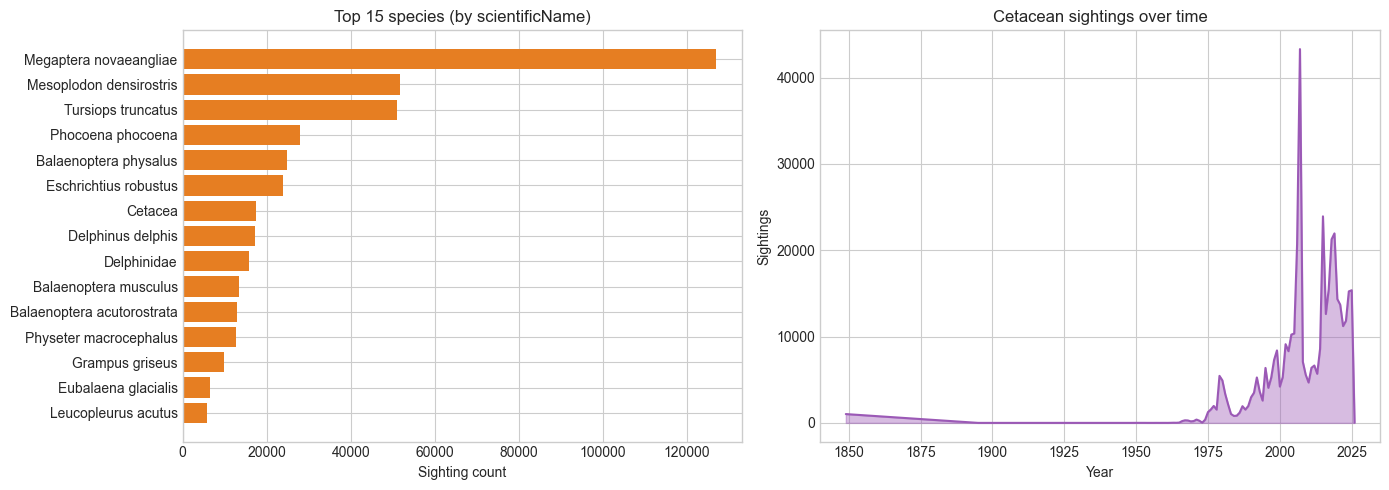

Year range: 1849 — 2026
Peak year: 2007 (43,313 sightings)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top species by count
sp_counts = cet_df["scientificName"].value_counts().head(15)
axes[0].barh(sp_counts.index[::-1], sp_counts.values[::-1], color="#e67e22")
axes[0].set_xlabel("Sighting count")
axes[0].set_title("Top 15 species (by scientificName)")

# Temporal distribution
year_counts = cet_df["date_year"].dropna().astype(int).value_counts().sort_index()
axes[1].fill_between(year_counts.index, year_counts.values, alpha=0.4, color="#9b59b6")
axes[1].plot(year_counts.index, year_counts.values, color="#9b59b6")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Sightings")
axes[1].set_title("Cetacean sightings over time")

plt.tight_layout()
plt.show()

print(f"Year range: {int(year_counts.index.min())} — {int(year_counts.index.max())}")
print(f"Peak year: {year_counts.idxmax()} ({year_counts.max():,} sightings)")

## 6. MPA geometry health

Checking for invalid geometries (self-intersections, topology errors) that could cause spatial join failures downstream.

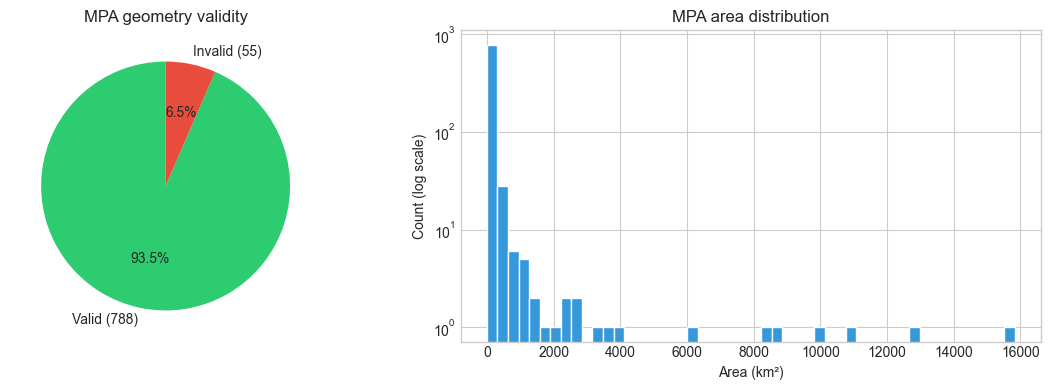

Valid: 788, Invalid: 55, Empty: 0
Note: Invalid geometries will be fixed with ST_MakeValid() in dbt


In [13]:
n_valid = mpa_gdf.geometry.is_valid.sum()
n_invalid = (~mpa_gdf.geometry.is_valid).sum()
n_empty = mpa_gdf.geometry.is_empty.sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Geometry validity pie chart
axes[0].pie(
    [n_valid, n_invalid],
    labels=[f"Valid ({n_valid})", f"Invalid ({n_invalid})"],
    colors=["#2ecc71", "#e74c3c"],
    autopct="%1.1f%%",
    startangle=90,
)
axes[0].set_title("MPA geometry validity")

# MPA area distribution (log scale)
area = mpa_gdf["AreaKm"][mpa_gdf["AreaKm"] > 0]
axes[1].hist(area, bins=50, color="#3498db", edgecolor="white", log=True)
axes[1].set_xlabel("Area (km²)")
axes[1].set_ylabel("Count (log scale)")
axes[1].set_title("MPA area distribution")

plt.tight_layout()
plt.show()

print(f"Valid: {n_valid}, Invalid: {n_invalid}, Empty: {n_empty}")
print("Note: Invalid geometries will be fixed with ST_MakeValid() in dbt")

## 7. Key takeaways

| Finding | Impact | Action |
|---|---|---|
| AIS heading 48% complete | Cannot rely on heading for direction | Use `cog` (83% complete) instead |
| AIS SOG 66% zeros | Stationary vessels dominate | Filter `sog > 0` for collision risk |
| AIS draft 58% complete | Can't reliably determine vessel load | Infer from `length`/`width` (~97%) |
| MPA 55 invalid geometries | Spatial joins may fail or give wrong results | Fix with `ST_MakeValid()` in dbt |
| Cetacean species 89% complete | 11% identified to genus/family only | Use `scientificName` as primary key (100% complete) |
| All schemas pass ✅ | Data is structurally sound | Safe to proceed to dbt transformations |